# Experimento 1: MicaSense + GLCM (split unico 70/20/10)


## Requisitos
Paquetes base: numpy, pandas, scipy, scikit-learn.
Para lectura y segmentacion: imageio, Pillow y opcionalmente scikit-image (Otsu).


## Librerias
Se importan utilidades, modelos y herramientas de validacion cruzada.


In [1]:
from __future__ import annotations

import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.io as sio

from sklearn.model_selection import GroupShuffleSplit, GroupKFold, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer


## Estructura del dataset
El notebook busca `DATASET1/` y si no existe usa `DATASET/`.
Por especie se esperan:
- `FMC_*.mat`: matriz N x 5 (N hojas, 5 etapas).
- `Multispectral Images/`: `leaf###dY_X.tif`.

Convencion:
- `###`: id de hoja (0 a N-1).
- `Y`: etapa (0 a 4).
- `X`: banda (1=B, 2=G, 3=R, 4=NIR, 5=RE).


## Configuracion
Define especie y tipo de FMC. Usa ASCII para evitar problemas de codificacion.


In [2]:
DATASET_ROOT = Path("/home/jorge_uc/UC/3/P1/DATASET")
if not DATASET_ROOT.exists():
    raise FileNotFoundError("No se encontro DATASET en /home/jorge_uc/UC/3/P1/DATASET.")

SPECIES = "Avocado"  # Avocado | Olive | Vineyard
TARGET_KIND = "f"     # "f" para FMC_f (fresh basis) o "d" para FMC_d (dry basis)
EPS = 1e-6
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
SPLIT_CSV_PATH = DATASET_ROOT / "split_unico_70_20_10.csv"


## Carga de FMC (.mat) y etiquetas
Se lee FMC_f o FMC_d y se transforma a un DataFrame largo con:
`leaf_id`, `stage`, `fmc`.


In [3]:
def get_species_paths(species: str) -> dict:
    folder = DATASET_ROOT / species
    if species == "Vineyard":
        fmc_path = folder / "FMC_vineyard.mat"
    elif species == "Olive":
        fmc_path = folder / "FMC_olive.mat"
    elif species == "Avocado":
        fmc_path = folder / "FMC_avocado.mat"
    else:
        raise ValueError(f"Especie no reconocida: {species}")
    img_dir = folder / "Multispectral Images"
    return {"fmc_path": fmc_path, "img_dir": img_dir}

paths = get_species_paths(SPECIES)
fmc_path = paths["fmc_path"]

with open(fmc_path, "rb") as f:
    mat = sio.loadmat(f)

fmc_f_key = [k for k in mat.keys() if k.lower().startswith("fmc_f")][0]
fmc_d_key = [k for k in mat.keys() if k.lower().startswith("fmc_d")][0]

fmc_f = mat[fmc_f_key]
fmc_d = mat[fmc_d_key]

fmc = fmc_f if TARGET_KIND == "f" else fmc_d
n_leaves, n_stages = fmc.shape

rows = []
for leaf_id in range(n_leaves):
    for stage in range(n_stages):
        rows.append({
            "leaf_id": leaf_id,
            "stage": stage,
            "fmc": float(fmc[leaf_id, stage]),
        })

fmc_df = pd.DataFrame(rows)
fmc_df.head()


,leaf_id,stage,fmc
0,0,0,51.587916
1,0,1,42.075996
2,0,2,30.245536
3,0,3,16.555407
4,0,4,0.000000


## Indexado de imagenes
Se mapean rutas por `(leaf_id, stage)` y banda.


In [4]:
img_dir = paths["img_dir"]
pattern = re.compile(r"leaf(\d{3})d(\d)_([1-5])\.tif", re.IGNORECASE)

index = {}
for p in img_dir.glob("*.tif"):
    m = pattern.match(p.name)
    if not m:
        continue
    leaf_id = int(m.group(1))
    stage = int(m.group(2))
    band = int(m.group(3))
    index.setdefault((leaf_id, stage), {})[band] = p

len(index), list(index.items())[:2]


(520,
 [((36, 1),
   {5: PosixPath('/home/jorge_uc/UC/3/P1/DATASET/Avocado/Multispectral Images/leaf036d1_5.tif'),
    4: PosixPath('/home/jorge_uc/UC/3/P1/DATASET/Avocado/Multispectral Images/leaf036d1_4.tif'),
    1: PosixPath('/home/jorge_uc/UC/3/P1/DATASET/Avocado/Multispectral Images/leaf036d1_1.tif'),
    2: PosixPath('/home/jorge_uc/UC/3/P1/DATASET/Avocado/Multispectral Images/leaf036d1_2.tif'),
    3: PosixPath('/home/jorge_uc/UC/3/P1/DATASET/Avocado/Multispectral Images/leaf036d1_3.tif')}),
  ((53, 1),
   {3: PosixPath('/home/jorge_uc/UC/3/P1/DATASET/Avocado/Multispectral Images/leaf053d1_3.tif'),
    1: PosixPath('/home/jorge_uc/UC/3/P1/DATASET/Avocado/Multispectral Images/leaf053d1_1.tif'),
    2: PosixPath('/home/jorge_uc/UC/3/P1/DATASET/Avocado/Multispectral Images/leaf053d1_2.tif'),
    4: PosixPath('/home/jorge_uc/UC/3/P1/DATASET/Avocado/Multispectral Images/leaf053d1_4.tif'),
    5: PosixPath('/home/jorge_uc/UC/3/P1/DATASET/Avocado/Multispectral Images/leaf053d1_5.tif')

## Features por banda y indices espectrales
Para cada banda se calculan:
- mean, median, std, p10, p90

Luego se agregan indices (usando medias por banda):
- NDVI = (NIR - R) / (NIR + R)
- NDRE = (NIR - RE) / (NIR + RE)
- NDWI = (G - NIR) / (G + NIR)  # version sin SWIR

Tambien se incluyen `nir_mean` y `re_mean` como features explicitas.


In [5]:
def read_tiff(path: Path) -> np.ndarray:
    try:
        import imageio.v3 as iio
        return iio.imread(path)
    except Exception:
        from PIL import Image
        return np.array(Image.open(path))


def get_mask(img: np.ndarray) -> np.ndarray:
    if img.ndim > 2:
        img = img[..., 0]
    img = img.astype(np.float32)
    try:
        from skimage.filters import threshold_otsu
        thr = threshold_otsu(img)
        return img > thr
    except Exception:
        return img > 0


def extract_stats(img: np.ndarray, mask: np.ndarray) -> dict:
    pixels = img[mask].astype(np.float32)
    if pixels.size == 0:
        return None
    return {
        "mean": float(np.mean(pixels)),
        "median": float(np.median(pixels)),
        "std": float(np.std(pixels)),
        "p10": float(np.percentile(pixels, 10)),
        "p90": float(np.percentile(pixels, 90)),
    }


## Construccion del dataset tabular
Se descartan muestras incompletas y se arma un DataFrame con features + fmc.


In [6]:
band_names = {1: "B", 2: "G", 3: "R", 4: "NIR", 5: "RE"}

records = []
for (leaf_id, stage), band_map in sorted(index.items()):
    if leaf_id >= n_leaves:
        continue
    if any(b not in band_map for b in band_names):
        continue

    sample = {
        "leaf_id": leaf_id,
        "stage": stage,
        "fmc": float(fmc[leaf_id, stage]),
    }

    ok = True
    for b, bname in band_names.items():
        img = read_tiff(band_map[b])
        mask = get_mask(img)
        stats = extract_stats(img, mask)
        if stats is None:
            ok = False
            break
        for k, v in stats.items():
            sample[f"{bname}_{k}"] = v

    if not ok:
        continue

    # Indices espectrales desde medias
    nir = sample["NIR_mean"]
    red = sample["R_mean"]
    re_b = sample["RE_mean"]
    green = sample["G_mean"]

    sample["ndvi"] = (nir - red) / (nir + red + EPS)
    sample["ndre"] = (nir - re_b) / (nir + re_b + EPS)
    sample["ndwi"] = (green - nir) / (green + nir + EPS)

    records.append(sample)

base_df = pd.DataFrame(records)
base_feature_cols = [c for c in base_df.columns if c not in {"leaf_id", "stage", "fmc"}]

# --- Integracion de GLCM desde Total_features.csv (50 features) ---
total_path = DATASET_ROOT / "Total_features.csv"
total_df = pd.read_csv(total_path)

species_map = {"Avocado": "Avocado", "Olive": "olive", "Vineyard": "vineyard"}
total_df = total_df[total_df["Species"] == species_map[SPECIES]].copy()

blue_paths = total_df["blue"].astype(str).str.replace("\\", "/", regex=False)
parsed = blue_paths.str.extract(r"leaf(\d{3})d(\d)_1\.tif", expand=True)
if parsed.isna().any().any():
    raise ValueError("No se pudieron parsear leaf_id/stage desde la columna blue en Total_features.csv")

total_df["leaf_id"] = parsed[0].astype(int)
total_df["stage"] = parsed[1].astype(int)

glcm_metrics = [
    "ASM", "contrast", "correlation", "dissimilarity", "energy",
    "entropy", "homogeneity", "mean", "std", "variance",
]
glcm_bands = ["B", "G", "R", "NIR", "RE"]
glcm_feature_cols = [f"{m}_{b}" for m in glcm_metrics for b in glcm_bands]

missing_cols = [c for c in glcm_feature_cols if c not in total_df.columns]
if missing_cols:
    raise KeyError(f"Faltan columnas GLCM en Total_features.csv: {missing_cols}")

glcm_df = total_df[["leaf_id", "stage"] + glcm_feature_cols].copy()

df = base_df.merge(
    glcm_df,
    on=["leaf_id", "stage"],
    how="inner",
    validate="one_to_one",
)

if len(df) != len(base_df):
    raise ValueError(f"Merge incompleto con Total_features.csv: {len(df)} vs {len(base_df)} muestras")

print(f"Features base: {len(base_feature_cols)} | GLCM: {len(glcm_feature_cols)} | Total: {len(base_feature_cols) + len(glcm_feature_cols)}")
df.head()


,leaf_id,stage,fmc,B_mean,B_median,B_std,B_p10,B_p90,G_mean,G_median,...,NIR_p10,NIR_p90,RE_mean,RE_median,RE_std,RE_p10,RE_p90,ndvi,ndre,ndwi
0,0,0,51.587916,2230.893066,2118.0,683.900696,1437.000000,3177.000000,3402.553467,3308.0,...,3692.0,7860.299805,8462.968750,8280.0,1920.958618,6134.0,11059.000000,0.308804,-0.197511,-0.250031
1,0,1,42.075996,2596.217041,2475.0,823.670776,1652.000000,3650.000000,4193.684082,4106.0,...,4503.0,9888.000000,7924.649414,7399.0,2793.106689,4907.0,11422.000000,0.366252,-0.059422,-0.253086
2,0,2,30.245536,10987.385742,10666.0,3498.063232,6613.399902,15814.200195,5244.833008,4196.0,...,6628.0,14820.700195,8363.926758,7429.0,3429.811523,5111.0,12847.299805,0.041125,0.107356,-0.328472
3,0,3,16.555407,7753.814941,6730.5,3225.947510,4475.000000,12626.400391,7753.814941,6730.5,...,3847.0,9302.000000,7161.029785,6373.0,3006.780273,4307.0,11080.000000,0.157542,-0.058380,0.097897
4,0,4,0.000000,11118.645508,10311.0,4020.641602,6556.500000,17054.000000,4584.100586,4033.0,...,5180.0,11218.200195,7149.074219,6797.5,2261.029053,4713.0,9902.299805,0.318384,0.059891,-0.274901


## Resumen rapido


In [7]:
print(f"Samples: {len(df)}")
print(f"Features: {df.shape[1] - 3} (excluyendo leaf_id, stage, fmc)")

df.describe().T.head(10)


Samples: 520
Features: 28 (excluyendo leaf_id, stage, fmc)


,count,mean,std,min,25%,50%,75%,max
leaf_id,520.0,51.500000,30.049734,0.000000,25.750000,51.500000,77.250000,103.000000
stage,520.0,2.000000,1.415575,0.000000,1.000000,2.000000,3.000000,4.000000
fmc,520.0,33.366536,20.872622,0.000000,17.593536,38.407226,51.309713,66.257669
B_mean,520.0,7818.018345,3840.238638,970.904907,3089.595886,9493.226074,10958.167725,13887.001953
B_median,520.0,7437.169231,3781.368394,916.000000,2764.250000,8908.000000,10567.000000,13831.000000
B_std,520.0,2456.939007,1078.054612,311.078491,1307.421753,2926.037964,3265.067566,4629.442871
B_p10,520.0,4914.925190,2425.202933,616.000000,1950.500000,5941.399902,6920.399902,9185.000000
B_p90,520.0,11225.974040,5454.069167,1385.000000,4323.750000,13996.100098,15482.074951,20668.400391
G_mean,520.0,5448.136718,2355.010095,1537.713501,3851.062378,4972.894775,6265.528931,13438.199219
G_median,520.0,4983.896154,2291.673858,1437.000000,3453.750000,4397.000000,5684.250000,12895.500000


## Entrenamiento con grid search
Se hace split por hoja (group = leaf_id) para evitar fuga de informacion.
El grid search se ejecuta solo en el set de entrenamiento usando GroupKFold.


In [8]:
# Features de entrada: MicaSense base + GLCM
feature_cols = list(dict.fromkeys(base_feature_cols + glcm_feature_cols))

split_df = pd.read_csv(SPLIT_CSV_PATH)
split_sub = split_df[split_df["species"] == SPECIES][["leaf_id", "stage", "split"]]

df_split = df.merge(
    split_sub,
    on=["leaf_id", "stage"],
    how="inner",
    validate="one_to_one",
)

if len(df_split) != len(df):
    raise ValueError(f"Split incompleto: {len(df_split)} vs {len(df)}")

X = df_split[feature_cols].values
y = df_split["fmc"].values
groups = df_split["leaf_id"].values

# Para CV usamos train+val, y dejamos test como holdout final
dev_mask = df_split["split"].isin(["train", "val"]).values
test_mask = df_split["split"].eq("test").values

X_train, X_test = X[dev_mask], X[test_mask]
y_train, y_test = y[dev_mask], y[test_mask]
groups_train = groups[dev_mask]

# Scorer RMSE (evita el arg squared para compatibilidad)
def rmse_score(y_true, y_pred):
    return -np.sqrt(mean_squared_error(y_true, y_pred))

rmse_scorer = make_scorer(rmse_score)

cv = GroupKFold(n_splits=5)

models = {
    "RandomForest": {
        "estimator": RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        "param_grid": {
            "n_estimators": [200, 500, 1000, 1500, 2000],
            "max_depth": [None, 10, 20, 30, 40, 60],
            "min_samples_leaf": [1, 2, 4, 8],
            "min_samples_split": [2, 5, 10, 20],
            "max_features": ["sqrt", "log2", 0.5],
        },
    },
    "SVR_RBF": {
        "estimator": Pipeline([
            ("scaler", StandardScaler()),
            ("svr", SVR(kernel="rbf")),
        ]),
        "param_grid": {
            "svr__C": [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0, 3000.0],
            "svr__gamma": ["scale", "auto", 0.0001, 0.001, 0.01, 0.1, 1.0],
            "svr__epsilon": [0.01, 0.05, 0.1, 0.2, 0.3, 0.5],
        },
    },
    "Ridge": {
        "estimator": Pipeline([
            ("scaler", StandardScaler()),
            ("ridge", Ridge()),
        ]),
        "param_grid": {
            "ridge__alpha": [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0, 3000.0, 10000.0],
        },
    },
    "ElasticNet": {
        "estimator": Pipeline([
            ("scaler", StandardScaler()),
            ("enet", ElasticNet(max_iter=10000)),
        ]),
        "param_grid": {
            "enet__alpha": [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
            "enet__l1_ratio": [0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9, 0.95],
        },
    },
    "GradientBoosting": {
        "estimator": GradientBoostingRegressor(random_state=RANDOM_STATE),
        "param_grid": {
            "n_estimators": [100, 200, 400, 600, 800, 1000],
            "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
            "max_depth": [2, 3, 4, 5],
            "subsample": [0.6, 0.8, 1.0],
        },
    },
}

best_models = {}

results = []
for name, cfg in models.items():
    grid = GridSearchCV(
        cfg["estimator"],
        cfg["param_grid"],
        scoring=rmse_scorer,
        cv=cv,
        n_jobs=-1,
    )
    grid.fit(X_train, y_train, groups=groups_train)

    cv_rmse_std = grid.cv_results_["std_test_score"][grid.best_index_]

    best = grid.best_estimator_
    best_models[name] = best

    mae_scores = cross_val_score(
        best,
        X_train,
        y_train,
        groups=groups_train,
        cv=cv,
        scoring=make_scorer(mean_absolute_error, greater_is_better=False),
        n_jobs=-1,
    )
    r2_scores = cross_val_score(
        best,
        X_train,
        y_train,
        groups=groups_train,
        cv=cv,
        scoring="r2",
        n_jobs=-1,
    )

    best_cv_mae = -mae_scores.mean()
    best_cv_mae_std = mae_scores.std()
    best_cv_r2 = r2_scores.mean()
    best_cv_r2_std = r2_scores.std()

    pred = best.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)

    results.append({
        "model": name,
        "best_cv_rmse": -grid.best_score_,
        "best_cv_rmse_std": cv_rmse_std,
        "best_cv_mae": best_cv_mae,
        "best_cv_mae_std": best_cv_mae_std,
        "best_cv_r2": best_cv_r2,
        "best_cv_r2_std": best_cv_r2_std,
        "test_rmse": rmse,
        "test_mae": mae,
        "test_r2": r2,
        "best_params": grid.best_params_,
    })

results_df = pd.DataFrame(results).sort_values(by="test_rmse")
results_df


/home/jorge_uc/UC/3/P1/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.059e+02, tolerance: 1.453e+01
  model = cd_fast.enet_coordinate_descent(
/home/jorge_uc/UC/3/P1/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.794e+02, tolerance: 1.454e+01
  model = cd_fast.enet_coordinate_descent(
/home/jorge_uc/UC/3/P1/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing reg

,model,best_cv_rmse,best_cv_rmse_std,test_rmse,test_mae,test_r2,best_params
0,RandomForest,12.633047,0.418852,12.357039,9.725806,0.638756,"{'max_depth': 10, 'min_samples_leaf': 1, 'min_..."
4,GradientBoosting,12.245080,0.578550,12.754112,10.069832,0.615168,"{'learning_rate': 0.03, 'max_depth': 4, 'n_est..."
1,SVR_RBF,12.641401,0.910532,14.707366,10.520394,0.488270,"{'svr__C': 100.0, 'svr__epsilon': 0.3, 'svr__g..."
3,ElasticNet,15.015211,0.971536,15.303224,11.992765,0.445965,"{'enet__alpha': 0.001, 'enet__l1_ratio': 0.9}"
2,Ridge,14.967177,1.013216,15.782880,12.119417,0.410690,{'ridge__alpha': 0.001}


In [ ]:
# Prediccion FMC: mejor modelo (por test_rmse)
best_row = results_df.iloc[0]
best_name = best_row["model"]
best_model = best_models[best_name]
best_pred = best_model.predict(X_test)

plt.figure(figsize=(5, 4))
plt.scatter(y_test, best_pred, s=12, alpha=0.7, color="#4C72B0")
min_v = min(y_test.min(), best_pred.min())
max_v = max(y_test.max(), best_pred.max())
plt.plot([min_v, max_v], [min_v, max_v], color="#C44E52", linewidth=2)
plt.xlabel("FMC real")
plt.ylabel("FMC predicho")
plt.title(f"Mejor modelo: {best_name}")
plt.tight_layout()

# Diagnostico opcional: todos los modelos
model_items = list(best_models.items())
fig, axes = plt.subplots(1, len(model_items), figsize=(4 * len(model_items), 4))
if len(model_items) == 1:
    axes = [axes]

for ax, (name, model) in zip(axes, model_items):
    pred = model.predict(X_test)
    min_v = min(y_test.min(), pred.min())
    max_v = max(y_test.max(), pred.max())
    ax.scatter(y_test, pred, s=10, alpha=0.6, color="#4C72B0")
    ax.plot([min_v, max_v], [min_v, max_v], color="#C44E52", linewidth=1.5)
    ax.set_title(name)
    ax.set_xlabel("FMC real")
    ax.set_ylabel("FMC predicho")

fig.tight_layout()


## Grafico de resultados del test set
Se muestran las metricas de test por modelo para comparar rendimiento.


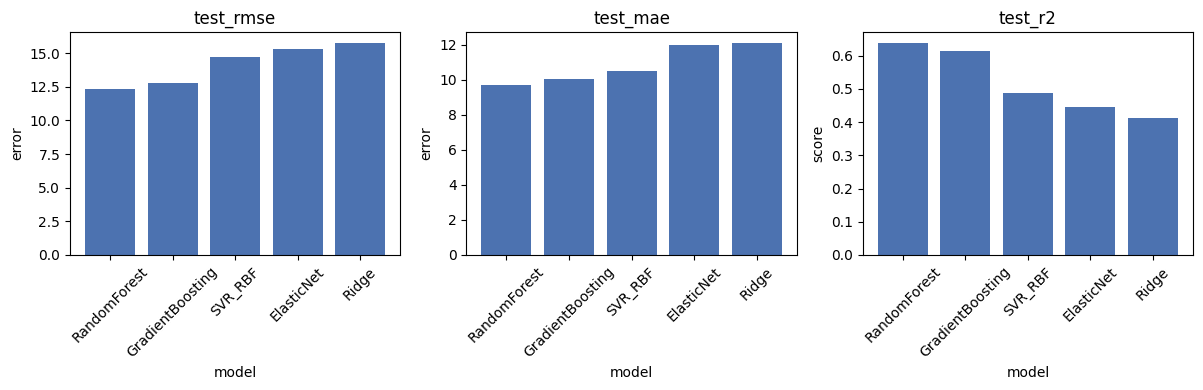

In [9]:
metrics = ["test_rmse", "test_mae", "test_r2"]
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, metric in zip(axes, metrics):
    ax.bar(results_df["model"], results_df[metric], color="#4C72B0")
    ax.set_title(metric)
    ax.set_xlabel("model")
    ax.tick_params(axis="x", rotation=45)
    if metric == "test_r2":
        ax.set_ylabel("score")
    else:
        ax.set_ylabel("error")

fig.tight_layout()


In [ ]:
# Guardado de modelos entrenados (joblib)
from pathlib import Path
import json
import joblib

EXPERIMENT_NAME = "Experimento1_micasense_modelos_grid_mas_amplio"
MODEL_EXPORT_ROOT = Path.cwd() / "trained_models_joblib"
species_tag = str(globals().get("SPECIES", "AllSpecies"))
target_tag = str(globals().get("TARGET_KIND", "na"))
out_dir = MODEL_EXPORT_ROOT / EXPERIMENT_NAME / species_tag / f"target_{target_tag}"
out_dir.mkdir(parents=True, exist_ok=True)

saved_paths = {}

# Caso general: modelos sklearn en best_models
if "best_models" in globals() and isinstance(best_models, dict):
    sklearn_models = {}
    for name, model in best_models.items():
        module_name = getattr(model.__class__, "__module__", "")
        is_keras_like = hasattr(model, "save") and ("keras" in module_name or "tensorflow" in module_name)

        if is_keras_like:
            keras_path = out_dir / f"{name}.keras"
            try:
                model.save(keras_path)
                saved_paths[name] = str(keras_path)
            except Exception as exc:
                saved_paths[name] = f"ERROR: {exc}"
        else:
            sklearn_models[name] = model

    if sklearn_models:
        sklearn_path = out_dir / "sklearn_models.joblib"
        joblib.dump(sklearn_models, sklearn_path)
        saved_paths["sklearn_models"] = str(sklearn_path)

# Caso CNN pura (experimento 7)
if "cnn" in globals():
    cnn_path = out_dir / "cnn_model.keras"
    try:
        cnn.save(cnn_path)
        saved_paths["cnn"] = str(cnn_path)
    except Exception as exc:
        saved_paths["cnn"] = f"ERROR: {exc}"

meta = {
    "experiment": EXPERIMENT_NAME,
    "species": species_tag,
    "target_kind": target_tag,
    "saved_paths": saved_paths,
    "n_features": int(len(feature_cols)) if "feature_cols" in globals() else None,
    "results_columns": list(results_df.columns) if "results_df" in globals() else None,
}
meta_path = out_dir / "model_artifacts.joblib"
joblib.dump(meta, meta_path)

print("Modelos/artefactos guardados en:", out_dir)
print(json.dumps(saved_paths, indent=2, ensure_ascii=False))
